In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

FREEZE = pd.Timestamp("2025-01-20")   # USAID funding freeze

df = pd.read_excel("Africa_CDC_Merged.xlsx")
df["Report Date"] = pd.to_datetime(df["Report Date"], errors="coerce")
df["month"] = df["Report Date"].dt.to_period("M").dt.to_timestamp()
df["post"]  = (df["Report Date"] >= FREEZE).astype(int)

print("Rows:", df.shape[0], "| Columns:", df.shape[1])
print("Date range:", df["Report Date"].min().date(), "->", df["Report Date"].max().date())
print("Countries:", df["Country"].nunique(), "| Diseases:", df["Agent/Syndrome"].nunique())

Rows: 2461 | Columns: 67
Date range: 2023-12-18 -> 2026-01-28
Countries: 41 | Diseases: 24


In [2]:
usaid = "USAID share of total ODA gross disbursements received, 2023"

country_usaid = df.groupby("Country")[usaid].first()
cutoff = country_usaid.median()
high_countries = country_usaid[country_usaid >= cutoff].index
df["treated"] = df["Country"].isin(high_countries).astype(int)

print(f"USAID-share median cutoff: {cutoff:.3f}")
print(f"High-dependence (treated): {len(high_countries)} countries")
print(f"Low-dependence          : {41 - len(high_countries)} countries")

USAID-share median cutoff: 0.120
High-dependence (treated): 21 countries
Low-dependence          : 20 countries


In [3]:
oda_pc  = "ODA gross disbursements received per person, 2023 (USD)"
oda_tot = "ODA gross disbursements received, 2023 (USD millions)"

per_country = df.groupby("Country").agg(
    usaid_share=(usaid, "first"),
    oda_per_capita=(oda_pc, "first"),
    oda_total_musd=(oda_tot, "first"),
).reset_index()

print(f"Mean USAID share of ODA : {per_country['usaid_share'].mean():.3f}")
print(f"Mean ODA per person     : ${per_country['oda_per_capita'].mean():.1f}")
print(f"Mean total ODA          : ${per_country['oda_total_musd'].mean():.0f}m")

Mean USAID share of ODA : 0.137
Mean ODA per person     : $78.0
Mean total ODA          : $1512m


In [4]:
dis = df.groupby("Agent/Syndrome").agg(
    n_reports=("Country", "size"),
    n_countries=("Country", "nunique"),
).reset_index().sort_values("n_reports", ascending=False)

dis.head(12)

,Agent/Syndrome,n_reports,n_countries
20,Vibrio cholerae,660,25
14,Mpox virus,620,29
13,Measles virus,523,27
6,Dengue virus,217,12
17,Polio virus (vaccine-derived),87,13
2,Bacterial meningitis,67,4
5,Corynebacterium diphtheriae,61,8
11,Lassa virus,47,4
22,Yellow fever virus,37,7
19,Rift Valley Fever,29,3


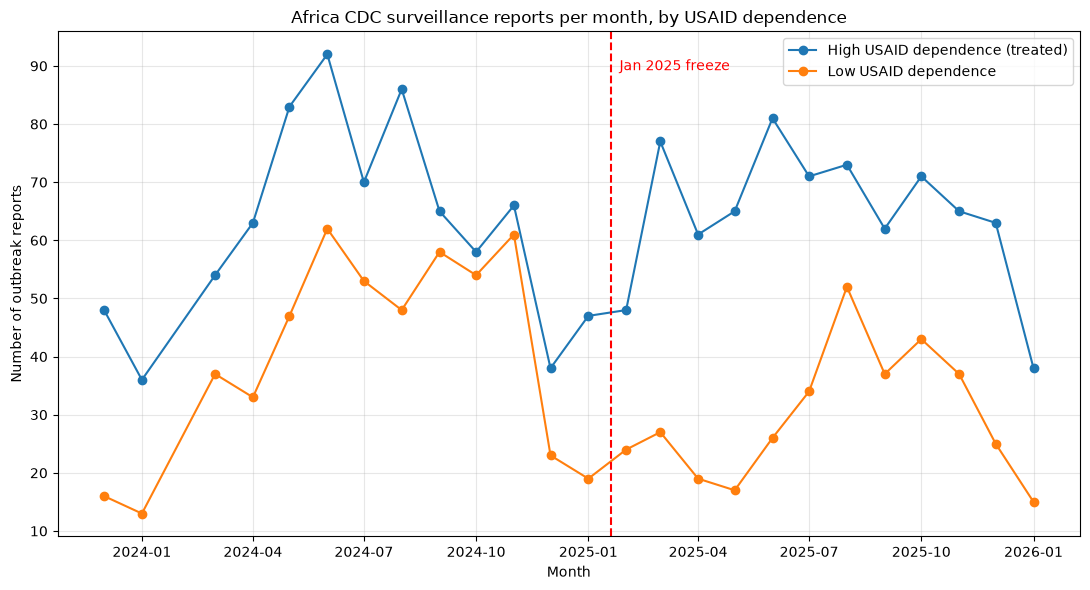

In [5]:
monthly = df.groupby(["month", "treated"]).size().reset_index(name="n")
pivot = monthly.pivot(index="month", columns="treated", values="n").fillna(0)
pivot.columns = ["Low USAID dependence", "High USAID dependence"]

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(pivot.index, pivot["High USAID dependence"], marker="o", label="High USAID dependence (treated)")
ax.plot(pivot.index, pivot["Low USAID dependence"],  marker="o", label="Low USAID dependence")
ax.axvline(FREEZE, color="red", linestyle="--", linewidth=1.5)
ax.text(FREEZE, ax.get_ylim()[1]*0.95, "  Jan 2025 freeze", color="red", va="top")
ax.set_title("Africa CDC surveillance reports per month, by USAID dependence")
ax.set_xlabel("Month"); ax.set_ylabel("Number of outbreak reports")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [6]:
pre = pivot[pivot.index < FREEZE]
corr = pre["Low USAID dependence"].corr(pre["High USAID dependence"])
print(f"Pre-freeze correlation: {corr:.3f}")
print("(~0.78: the groups moved together before the freeze -> parallel-trends looks plausible)")

Pre-freeze correlation: 0.782
(~0.78: the groups moved together before the freeze -> parallel-trends looks plausible)


In [7]:
tab = df.groupby(["Country", "treated", "post"]).size().unstack("post", fill_value=0)
tab.columns = ["pre_freeze", "post_freeze"]
tab["total"] = tab["pre_freeze"] + tab["post_freeze"]
pre_c  = tab["pre_freeze"].astype(float)
post_c = tab["post_freeze"].astype(float)
tab["pct_change"] = np.where(pre_c > 0, (post_c - pre_c) / pre_c * 100, np.nan).round(1)
tab = tab.reset_index().sort_values("total", ascending=False)
tab

,Country,treated,pre_freeze,post_freeze,total,pct_change
20,Mali,1,91,144,235,58.2
27,Nigeria,1,90,53,143,-41.1
3,Burundi,0,77,55,132,-28.6
30,Senegal,0,53,64,117,20.8
10,Democratic Republic of the Congo,1,85,27,112,-68.2
24,Mozambique,1,37,73,110,97.3
15,Kenya,1,39,66,105,69.2
11,Ethiopia,1,65,37,102,-43.1
35,Sudan,1,28,70,98,150.0
5,Cameroon,0,44,43,87,-2.3


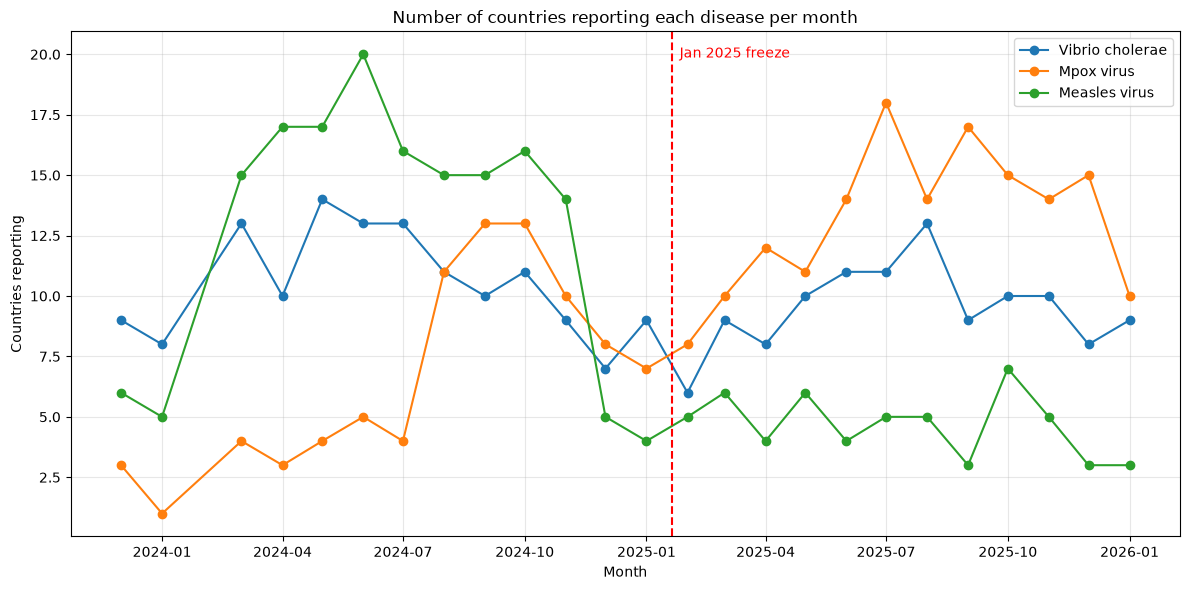

In [8]:
top_diseases = ["Vibrio cholerae", "Mpox virus", "Measles virus"]
sub = df[df["Agent/Syndrome"].isin(top_diseases)]
counts = (sub.groupby(["month", "Agent/Syndrome"])["Country"]
             .nunique().reset_index(name="n_countries"))
pv = counts.pivot(index="month", columns="Agent/Syndrome", values="n_countries").fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))
for d in top_diseases:
    if d in pv.columns:
        ax.plot(pv.index, pv[d], marker="o", label=d)
ax.axvline(FREEZE, color="red", linestyle="--", linewidth=1.5)
ax.text(FREEZE, ax.get_ylim()[1]*0.97, "  Jan 2025 freeze", color="red", va="top")
ax.set_title("Number of countries reporting each disease per month")
ax.set_xlabel("Month"); ax.set_ylabel("Countries reporting")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()